####======================================================
### **Homework Assignment 1**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing housing data from *AmesHousing.txt* to examine relationships between *SalePrice* and key property features. The dataset contains data on 2930 properties (rows) and has 82 features (columns), including *SalePrice*. The aim is to effectively model the variance of the dependent variable/target, *SalePrice*, as a function of 1 or more of the independent variables/features. To achieve this the sklearn, numpy, pandas, and matplotlib packages were used. The following steps were performed:

1. Values for 7 selected independent variables/features *(Overall Qual, Gr Liv Area, Total Bsmt SF, Bedroom AbvGr, Garage Area, Lot Area, TotRms AbvGrd)* and *SalePrice* were loaded into a DataFrame and the dataset was cleaned of rows with missing (NaN) values, leaving 2928 rows.

2. Scatter plots were generated to visualize the correlations between *SalePrice* and the 7 features.

3. A simple linear regression model was fitted using *Lot Area* to model *SalePrice*. The model prediction line was plotted against real data, and the *R²* value and model coefficients were found.

4. A multiple linear regression model was fitted using the full set of 7 features to predict *SalePrice*. For this, the dataset was split into a training set (70%) and a testing set (30%). The residual plots were displayed, and the *R²* values and model coefficients were found.

5. Data points (rows) with extreme outlier values in the feature set were identified and removed, leaving 2906 data points. The simple and multiple linear regression models were then refitted using the same steps as parts 3. and 4. along with the same associated outputs.

6. The simple linear regression models before and after removing outliers were graphed and compared on the same plot along with data points. The impact of removing extreme outliers on the modeling ability of both models was analyzed (change in *R²* values).









#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [ ]:
# list of columns to read from file
columns = ['Overall Qual',
           'Gr Liv Area',
           'Total Bsmt SF',
           'Bedroom AbvGr',
           'Garage Area',
           'Lot Area',
           'TotRms AbvGrd',

           'SalePrice']

# split columns into features and target
features = columns[:-1]
target = columns[-1]

# create dataframe (df) from the input file
df = pd.read_csv('AmesHousing.txt', sep = '\t', usecols = columns)

# display df head
df.head()

,Lot Area,Overall Qual,Total Bsmt SF,Gr Liv Area,Bedroom AbvGr,TotRms AbvGrd,Garage Area,SalePrice
0,31770,6,1080.0,1656,3,7,528.0,215000
1,11622,5,882.0,896,2,5,730.0,105000
2,14267,6,1329.0,1329,3,6,312.0,172000
3,11160,7,2110.0,2110,3,8,522.0,244000
4,13830,5,928.0,1629,3,6,482.0,189900


In [ ]:
# check df dimensions
df.shape

(2930, 8)

In [ ]:
# check df columns for missing values
df.isnull().sum()

,0
Lot Area,0
Overall Qual,0
Total Bsmt SF,1
Gr Liv Area,0
Bedroom AbvGr,0
TotRms AbvGrd,0
Garage Area,1
SalePrice,0


In [ ]:
# remove rows that contain missing (NaN) values
df = df.dropna(axis=0)
df.isnull().sum()

,0
Lot Area,0
Overall Qual,0
Total Bsmt SF,0
Gr Liv Area,0
Bedroom AbvGr,0
TotRms AbvGrd,0
Garage Area,0
SalePrice,0


In [ ]:
# check df dimensions
df.shape

(2928, 8)

#### ====================================================
#### VISUALIZE DATA/FEATURES
#### ======================================================

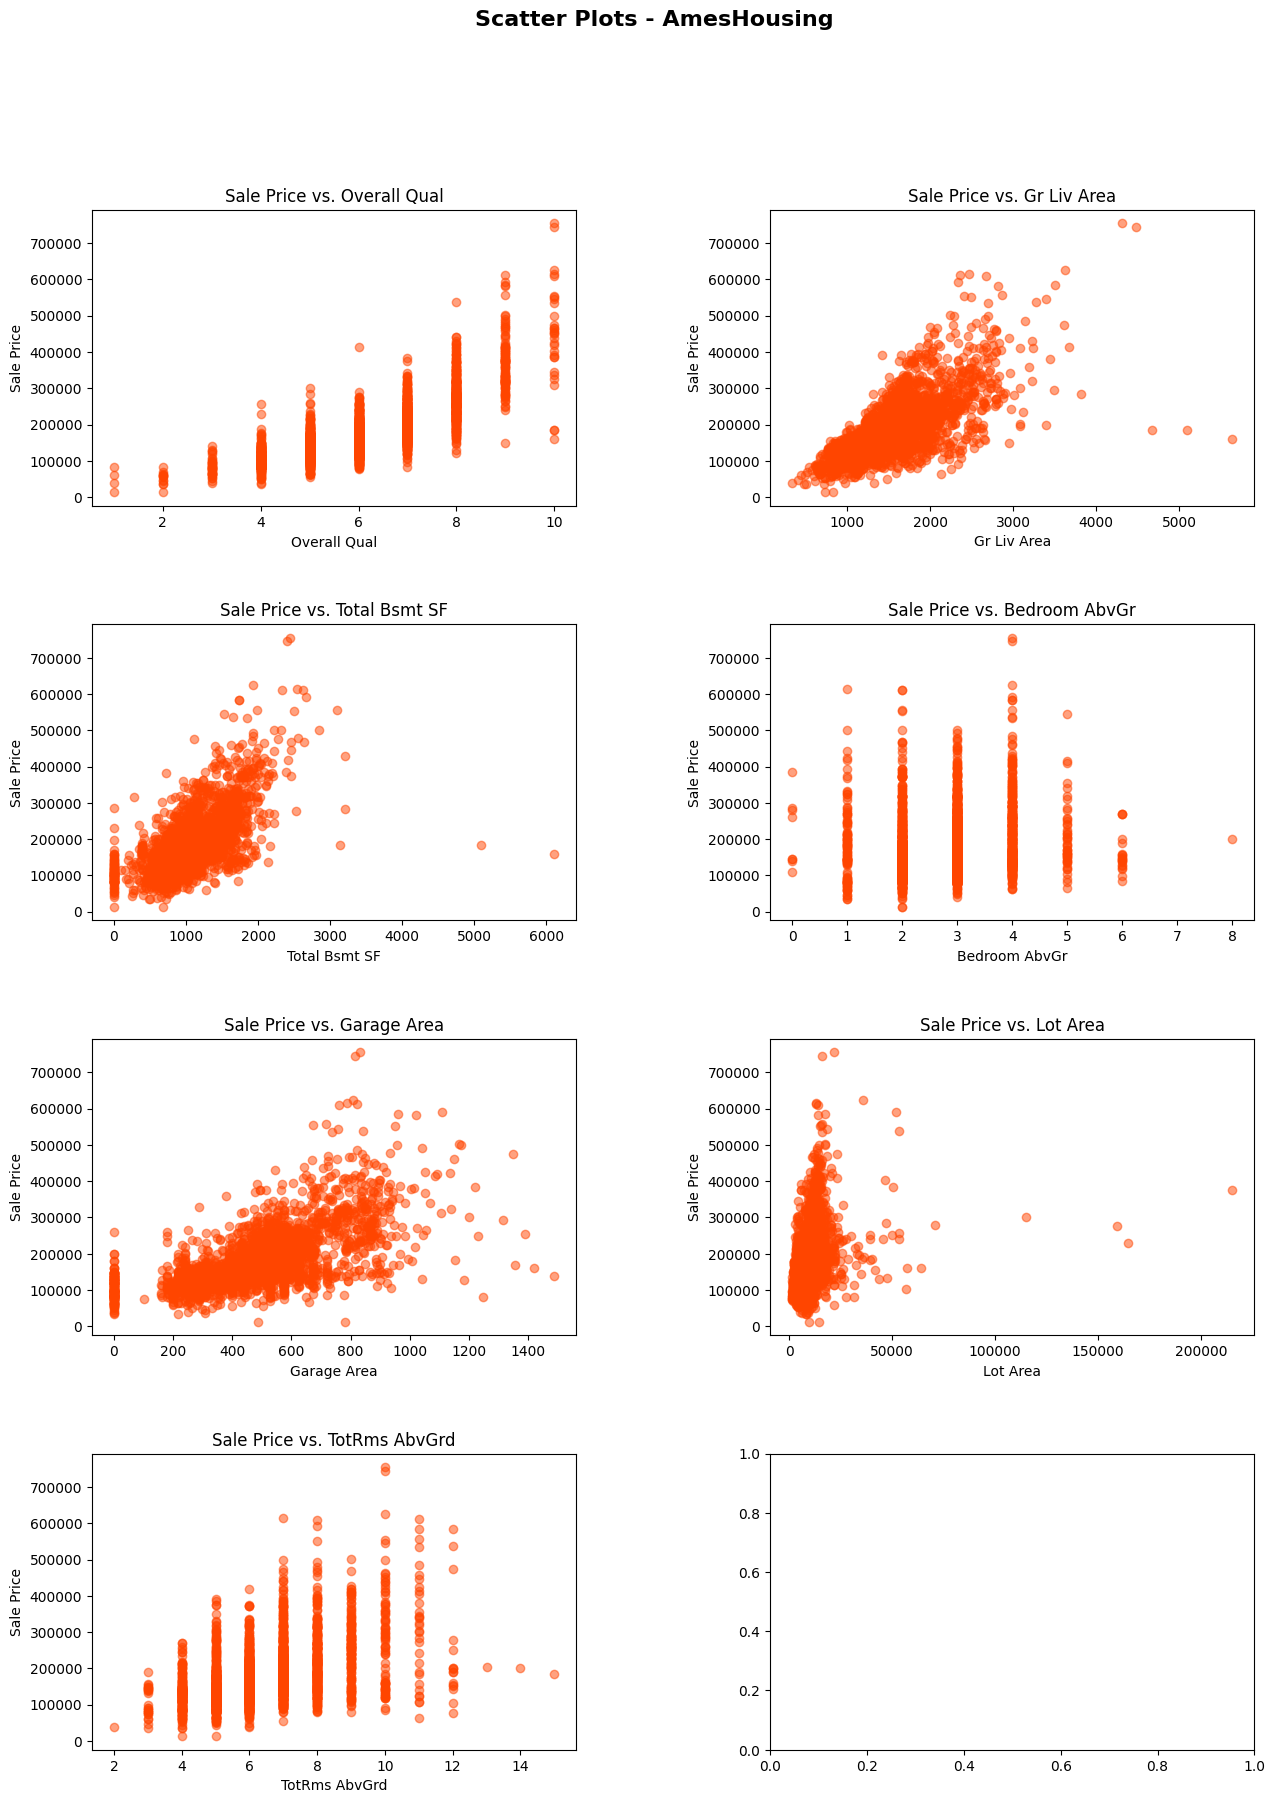

In [ ]:
# create a figure with subplots
n = len(features)
fig, axs = plt.subplots(((n + 1) // 2), 2, figsize = (15, 20))
axs = axs.flatten()

# make a plot for each feature
for idx, feature in enumerate(features):

    axs[idx].scatter(df[feature], df[target], alpha = 0.5, color = 'orangered')
    axs[idx].set(ylabel = 'Sale Price', xlabel = feature)
    axs[idx].set_title(f"Sale Price vs. {feature}")

# figure title
fig.suptitle("Scatter Plots - AmesHousing",fontsize = 16, fontweight = 'bold', ha = 'center', va = 'top')

# adjust spacing between subplots
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)

#### ====================================================
#### SIMPLE LINEAR REGRESSION MODEL 1
#### ======================================================

In [ ]:
# fit a simple linear regression model (SalePrice vs. Lot Area) using sklearn
SLR1 = LinearRegression()
X = df[['Lot Area']].values
y = df['SalePrice'].values
SLR1.fit(X, y)

# get predicted y-values
SLR1_ypred = SLR1.predict(X)

# saving X-values with outliers to display in a later graph
X_SLR1 = X

# output model coefficients
print(f'Slope: {SLR1.coef_[0]:.3f}')
print(f'Intercept: {SLR1.intercept_:.3f}')

Slope: 2.700
Intercept: 153436.864


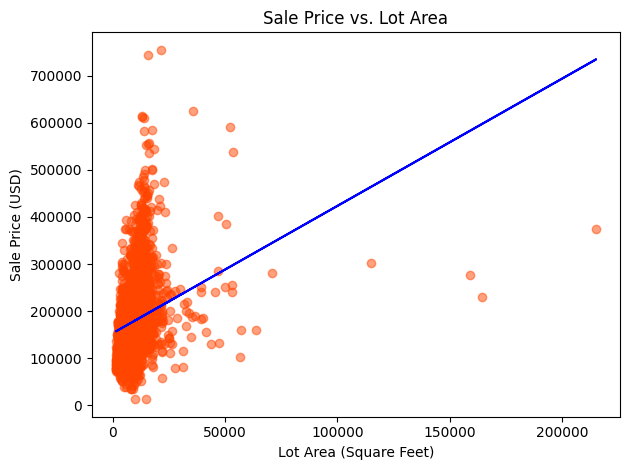

In [ ]:
# plot the data and the simple regression line
plt.scatter(X, y, alpha = 0.5, color = 'orangered')
plt.plot(X, SLR1_ypred, color='blue')

plt.title('Sale Price vs. Lot Area')
plt.xlabel('Lot Area (Square Feet)')
plt.ylabel('Sale Price (USD)')

plt.tight_layout()
plt.show()

In [ ]:
# compute R^2
print(f'R^2: {r2_score(y, SLR1_ypred):.3f}')

R^2: 0.071


#### ====================================================
#### MULTIPLE LINEAR REGRESSION MODEL 1
#### ======================================================

In [ ]:
# split the dataset into a training set and a testing set
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 45)

# fit a multiple linear regression model using 7 features
# fit the model with the training data, and make prediction on both train and test data
MLR1 = LinearRegression()
MLR1.fit(X_train, y_train)

MLR1_ypred_train = MLR1.predict(X_train)
MLR1_ypred_test = MLR1.predict(X_test)

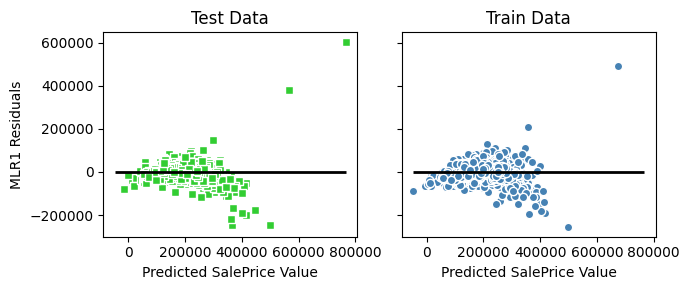

In [ ]:
# plot the residuals of the multiple linear regression model MLR1 to see that they are randomly scattered around mean = 0
x_max = np.max([np.max(MLR1_ypred_train), np.max(MLR1_ypred_test)])
x_min = np.min([np.min(MLR1_ypred_train), np.min(MLR1_ypred_test)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(MLR1_ypred_test, MLR1_ypred_test - y_test, color = 'limegreen', marker = 's', edgecolor = 'white')
ax1.set_title(f"Test Data")
ax2.scatter(MLR1_ypred_train, MLR1_ypred_train - y_train, color = 'steelblue', marker = 'o', edgecolor = 'white')
ax2.set_title(f"Train Data")

ax1.set_ylabel('MLR1 Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted SalePrice Value')
    ax.hlines(y = 0, xmin = x_min - 100, xmax = x_max + 100, color = 'black', lw = 2)

plt.tight_layout()
plt.show()

In [ ]:
# output model coefficients and intercept
coef_df = pd.DataFrame({'Feature': df[features].columns, 'Coefficient': MLR1.coef_})
coef_df.loc[len(coef_df)] = ['Intercept', MLR1.intercept_]
coef_df['Coefficient'] = coef_df['Coefficient'].apply(lambda x: f"{x:.3f}")
coef_df

,Feature,Coefficient
0,Overall Qual,22984.179
1,Gr Liv Area,60.241
2,Total Bsmt SF,33.442
3,Bedroom AbvGr,-9725.901
4,Garage Area,54.266
5,Lot Area,0.646
6,TotRms AbvGrd,-1359.884
7,Intercept,-80855.315


In [ ]:
# compute and output R^2 values for the model on the train and test dataset
r2_train = r2_score(y_train, MLR1_ypred_train)
r2_test =r2_score(y_test, MLR1_ypred_test)

print(f'R^2 train: {r2_train:.3f}')
print(f'R^2 test: {r2_test:.3f}')

R^2 train: 0.809
R^2 test: 0.744


#### ====================================================
#### REMOVE OUTLIERS
#### ======================================================

In [ ]:
# remove outlier rows with any of the following:

# Lot Area > 100000
# Total Bsmt SF > 3000
# Gr Liv Area > 4000
# TotRms AbvGrd > 12
# Garage Area > 1200

# drop outlier rows from the dataframe
df = df[df['Lot Area'] <= 100000]
df = df[df['Total Bsmt SF'] <= 3000]
df = df[df['Gr Liv Area'] <= 4000]
df = df[df['TotRms AbvGrd'] <= 12]
df = df[df['Garage Area'] <= 1200]


In [ ]:
# check df dimensions
df.shape

(2906, 8)

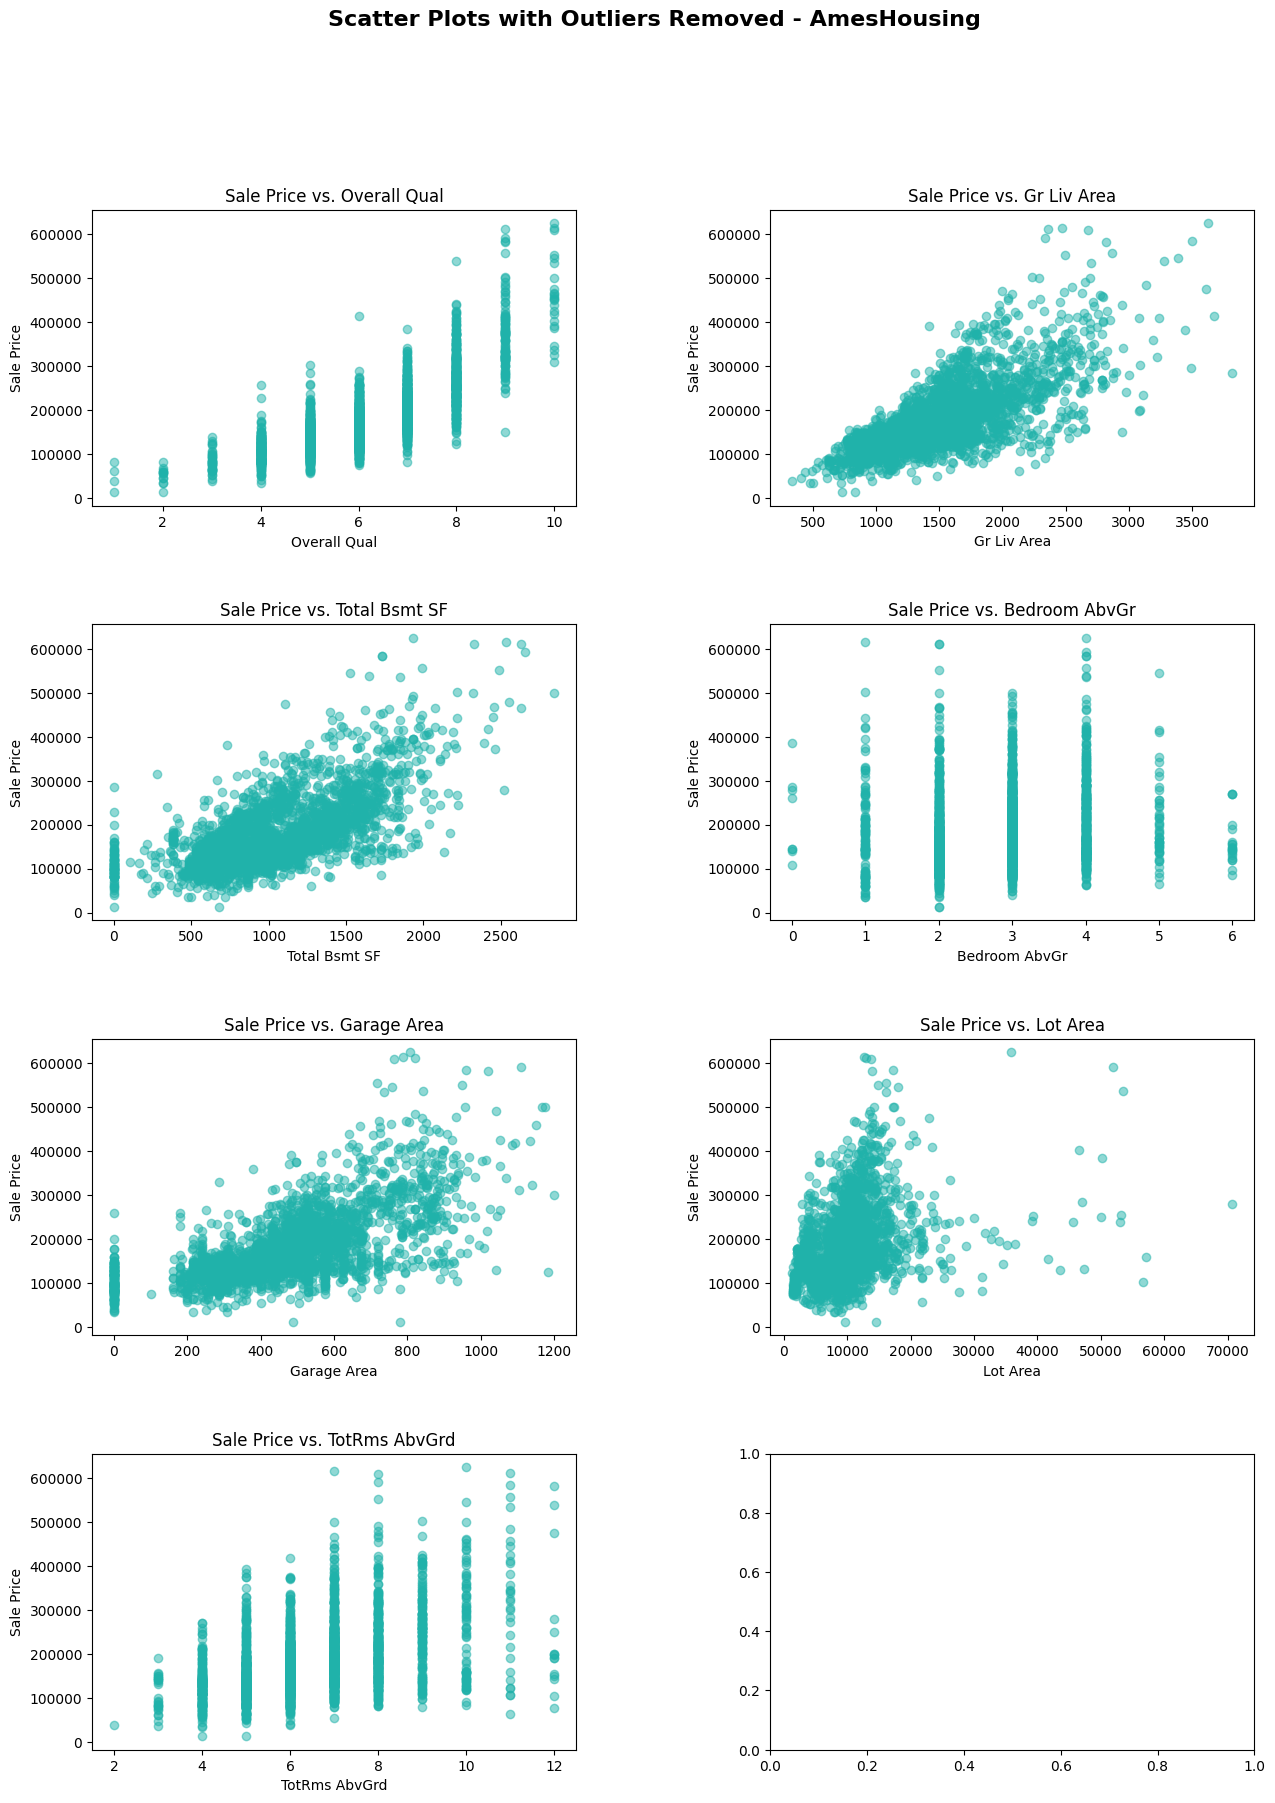

In [ ]:
# create a figure with subplots
n = len(features)
fig, axs = plt.subplots(((n + 1) // 2), 2, figsize = (15, 20))
axs = axs.flatten()

# make a plot for each feature
for idx, feature in enumerate(features):

    axs[idx].scatter(df[feature], df[target], alpha = 0.5, color = 'lightseagreen')
    axs[idx].set(ylabel = 'Sale Price', xlabel = feature)
    axs[idx].set_title(f"Sale Price vs. {feature}")

# figure title
fig.suptitle("Scatter Plots with Outliers Removed - AmesHousing", fontsize = 16, fontweight = 'bold', ha = 'center', va = 'top')

# adjust spacing between subplots
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)

#### ====================================================
#### SIMPLE LINEAR REGRESSION MODEL 2
#### ======================================================

In [ ]:
# fit a simple linear regression model (SalePrice vs. Lot Area) using sklearn
SLR2 = LinearRegression()
X = df[['Lot Area']].values
y = df['SalePrice'].values
SLR2.fit(X, y)

# get predicted y-values
SLR2_ypred = SLR2.predict(X)

# output model coefficients
print(f'Slope: {SLR2.coef_[0]:.3f}')
print(f'Intercept: {SLR2.intercept_:.3f}')

Slope: 5.237
Intercept: 128105.150


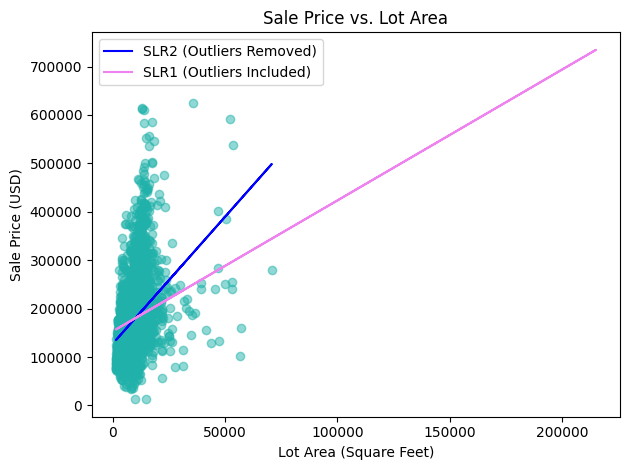

In [ ]:
# plot the data and the simple regression line SLR2
plt.scatter(X, y, alpha = 0.5, color = 'lightseagreen')
plt.plot(X, SLR2_ypred, color='blue', label = 'SLR2 (Outliers Removed)')

# add the regression line from SLR1 to the plot in order to compare it to SLR2
plt.plot(X_SLR1, SLR1_ypred, color='violet', label = 'SLR1 (Outliers Included)')

plt.title('Sale Price vs. Lot Area')
plt.xlabel('Lot Area (Square Feet)')
plt.ylabel('Sale Price (USD)')

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# output R^2
r2 = r2_score(y, SLR2_ypred)
print(f'R^2: {r2:.3f}')

R^2: 0.120


#### ====================================================
#### MULTIPLE LINEAR REGRESSION MODEL 2
#### ======================================================

In [ ]:
# split the dataset into a training set and a testing set
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 45)

# fit a multiple linear regression model using 7 features
# fit the model with the training data, and make prediction on both train and test data
MLR2 = LinearRegression()
MLR2.fit(X_train, y_train)

MLR2_ypred_train = MLR2.predict(X_train)
MLR2_ypred_test = MLR2.predict(X_test)

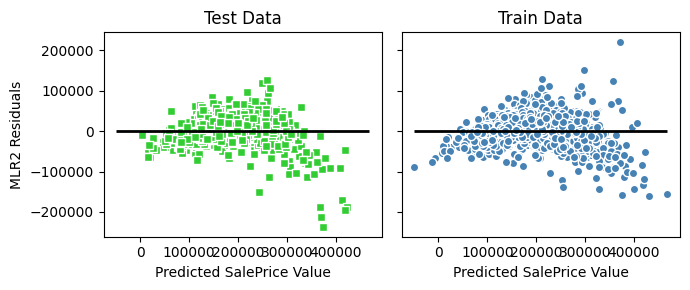

In [ ]:
# plot the residuals of the multiple linear regression model MLR1 to see that they are randomly scattered around mean = 0
x_max = np.max([np.max(MLR2_ypred_train), np.max(MLR2_ypred_test)])
x_min = np.min([np.min(MLR2_ypred_train), np.min(MLR2_ypred_test)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(MLR2_ypred_test, MLR2_ypred_test - y_test, color = 'limegreen', marker = 's', edgecolor = 'white')
ax1.set_title(f"Test Data")
ax2.scatter(MLR2_ypred_train, MLR2_ypred_train - y_train, color = 'steelblue', marker = 'o', edgecolor = 'white')
ax2.set_title(f"Train Data")

ax1.set_ylabel('MLR2 Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted SalePrice Value')
    ax.hlines(y = 0, xmin = x_min - 100, xmax = x_max + 100, color = 'black', lw = 2)

plt.tight_layout()
plt.show()

In [ ]:
# output model coefficients and intercept
coef_df = pd.DataFrame({'Feature': df[features].columns, 'Coefficient': MLR2.coef_})
coef_df.loc[len(coef_df)] = ['Intercept', MLR2.intercept_]
coef_df['Coefficient'] = coef_df['Coefficient'].apply(lambda x: f"{x:.3f}")
coef_df

,Feature,Coefficient
0,Overall Qual,22092.774
1,Gr Liv Area,61.228
2,Total Bsmt SF,33.685
3,Bedroom AbvGr,-11520.101
4,Garage Area,53.350
5,Lot Area,1.438
6,TotRms AbvGrd,-60.618
7,Intercept,-87252.876


In [ ]:
# compute and output R^2 values for the model on the train and test dataset
r2_train = r2_score(y_train, MLR2_ypred_train)
r2_test =r2_score(y_test, MLR2_ypred_test)

print(f'R^2 train: {r2_train:.3f}')
print(f'R^2 test: {r2_test:.3f}')

R^2 train: 0.838
R^2 test: 0.818


#### ====================================================
#### CONCLUSION + DISCUSSION
#### ======================================================

By removing the outlier data points and rebuilding the simple and multiple linear regression models, the R^2 values were improved in both the simple and the multiple regression models.
____________________________________________________________

**Simple Linear Regression Model:**

0.071 ==> 0.120
____________________________________________________________

**Multiple Linear Regression Model:**

**Train Set:** 0.809 ==> 0.838

**Test Set:** 0.744 ==> 0.818
____________________________________________________________

In the case of the multiple linear regression model, the full dataset was split into a training and testing dataset to avoid overfitting the data. This can often occur when a model with many degrees of freedom (many input variables) 'learns' to fit itself to the existing data points, rather than 'learning' the underlying patterns. This can provide a high R^2 value for the training set, but then quickly drop off to a bad R^2 value for the testing data set when the model encounters data it has not seen before. A good way to gauge whether a model is overfitting (bad) or generalizable (good) is to the compare the fit of the model on the training set vs. the testing set.

In the case of the 7-predictor model there is a good improvement in the model's fit on the training dataset, indicating that by removing the outliers from the dataset, the fit improved (R^2: 0.809 ==> 0.838). More notably, the fit of the model on the test dataset improved significantly and closed the gap with the training R^2 value (R^2: 0.744 ==> 0.818) indicating that the second model's explanatory/predictive power 'holds up' much better with new data. This intuitively makes sense, since a few large outliers would not only cause the largest prediction errors, but also most strongly influence the loss funtion/model coefficients. Overall, removing the outliers greatly improved the model, and with a R^2 > 0.800, the model is good.